In [1]:
import datetime
import pathlib

import pandas as pd
import numpy as np
import xarray as xr
import tensorflow as tf

import matplotlib.pyplot as plt

from scipy.stats import pearsonr

from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from dateutil.relativedelta import relativedelta

2024-11-07 08:47:12.983884: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512_VNNI
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-07 08:47:13.148411: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
src_path = pathlib.Path('/gpfs/work2/0/prjs1027/swn-runs/02-2022/computations/ens30')
write_dir = pathlib.Path("/gpfs/work2/0/prjs1027/guus/data")

In [3]:
tfrecord_dir = pathlib.Path('/gpfs/work2/0/prjs1027/tfrecords/run2')
output_variables = ["hs", "theta0_x", "theta0_y", "tmm10", "tps", "hswe"]
important_output_variables = ["hs", "tmm10", "tps", "hswe"]
vmins = [0, -1, -1, 0, 0, 0]
input_variables = ["xwnd", "ywnd", "ssh", "xcur", "ycur"]
boundary_variables = ["hs_bnd", "hswe_bnd", "tmm10_bnd"]
variable_fields = input_variables + output_variables + boundary_variables

min_max_values = xr.open_dataset(tfrecord_dir / "min-max-values/min-max-values-all.nc")

for bnd_var in boundary_variables:
    min_max_values[bnd_var] = min_max_values[bnd_var.split("_")[0]]

min_max_values["theta0_x"] = xr.DataArray(np.array([-1, 1.]), dims='index')
min_max_values["theta0_y"] = xr.DataArray(np.array([-1, 1.]), dims='index')

boundary_variables = ["Hm0", "HE10", "Tmm10"]
conversion_dict = {"Hm0": "hs", "HE10": "hswe", "Tmm10": "tmm10"}

In [4]:
def normalize(data, var):
    data = (data - min_max_values[var].values[0]) / (min_max_values[var].values[1] - min_max_values[var].values[0])
    return data

def denormalize(data, var):
    data = data * (min_max_values[var].values[1] - min_max_values[var].values[0]) + min_max_values[var].values[0]
    return data

In [5]:
learning_rate = 1e-4
n_epochs = 100
batch_size = 16
steps_per_execution = 1

model_version = "swan_ens_nn_v0005"

src_dir = pathlib.Path().resolve().parent
model_dir = src_dir / f"trained_models/{model_version}"
model_dir.mkdir(exist_ok=True, parents=True)

figure_dir = model_dir / 'figures'
figure_dir.mkdir(exist_ok=True, parents=True)

raster_shape = (481, 421, 2)
widths = [16, 32, 64, 128, 256, 256]
block_depth = 3

In [6]:
model = tf.keras.models.load_model(model_dir / (model_version + '.h5'))
model.summary()

2024-11-07 08:47:16.292080: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512_VNNI
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-07 08:47:16.770153: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18337 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB MIG 3g.20gb, pci bus id: 0000:31:00.0, compute capability: 8.0


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 481, 421, 1  0           []                               
                                0)]                                                               
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 512, 512, 10  0          ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 512, 512, 10  40         ['zero_padding2d[0][0]']         
 alization)                     )                                                             

In [7]:
locations = {
    "europlatform": {"longitude": 3.276389, "latitude": 51.998611},
    "ijmuiden munitiestort 1": {"longitude": 4.058333, "latitude": 52.55},
    "platform k13a": {"longitude": 3.220278, "latitude": 53.217778},
    "Q11": {"longitude": 4.150286, "latitude": 52.925353},
    "L91": {"longitude": 4.9607, "latitude": 53.6138},
    "wadden eierlandse gat": {"longitude": 4.661667, "latitude": 53.276944},
    "J61": {"longitude": 2.9167, "latitude": 53.7667},
    "platform f3": {"longitude": 4.7167, "latitude": 54.85},
    "A122": {"longitude": 3.8168, "latitude": 55.418},
    "Ekofisk": {"longitude": 3.2244, "latitude": 56.543},
    "nelson_platform_1": {"longitude": 1.145, "latitude": 57.66169},
    "gannet_platform_1": {"longitude": 1, "latitude": 57.18503},
    "Granefeltet": {"longitude": 2.4873, "latitude": 59.165},
    "north cormorant 1": {"longitude": 1.149444, "latitude": 61.24},
    "Schiermonnikoog Noord": {"longitude": 6.166667, "latitude": 53.595556},
    "Westhinder WHIN": {"longitude": 2.438889, "latitude": 51.380833}
}


In [8]:
val_ds = xr.load_dataset(write_dir / 'validation_ens30.nc')
# val_ds = xr.load_dataset(write_dir / 'validation_storm2018_ens30.nc')
# val_ds = xr.where(np.isnan(val_ds), -9, val_ds)

In [9]:
start_date = datetime.datetime.strptime('2018-01', '%Y-%m')
end_date = (start_date + relativedelta(months=1)) - relativedelta(minutes=1)

val_ds = val_ds.sel(time=slice(start_date, end_date))

In [9]:
bc_ds = xr.open_dataset(pathlib.Path(
    "/gpfs/work2/0/prjs1027/guus/data/BoundaryConditions/bnd.nc"
))

# bc_ds = xr.open_dataset(pathlib.Path('/gpfs/work2/0/prjs1027/guus/data/BoundaryConditions/bnd_storms.nc'))

In [10]:
times = val_ds.time.values

In [11]:
wave_heights = []
wave_heights_true = []

ens_30_pred = {}
ens_30_true = {}
for var in output_variables:
    ens_30_pred[var] = []
    ens_30_true[var] = []
    
for i in range(len(times)):
    input_data = {}
    boundary_data = {}
    for var in input_variables:
        data = val_ds[var].values

        shapes = data.shape
        
        field = np.empty((1, shapes[1], shapes[2], 2))
        field[..., 0] = val_ds[var].sel(time=times[i - 1]).values
        field[..., 1] = val_ds[var].sel(time=times[i]).values

        field = normalize(field, var)
        field[np.where(np.isnan(field))] = -9

        input_data[var] = field
        
    for var in boundary_variables:
        data = bc_ds[var].sel(time=times[i]).values[np.newaxis, ..., np.newaxis]
        data = normalize(data, conversion_dict[var])
        boundary_data[var] = data

    input_fields = np.concatenate([input_data[var] for var in input_variables], axis=-1)
    bc_data = np.concatenate([boundary_data[var] for var in boundary_variables], axis=-1)
    pred = model.predict((input_fields, bc_data))

    for j, var in enumerate(output_variables):
        if var in important_output_variables:
            ens_30_pred[var].append(denormalize(pred, var)[0, ..., j])
            ens_30_true[var].append(val_ds.sel(time=times[i])[var].values)

    # wave_heights.append(denormalize(pred[0, index_lat, index_lon, 0], 'hs'))
    # wave_heights_true.append(val_ds.sel(time=times[i])['hs'].values[index_lat, index_lon])

2024-11-07 08:47:54.309372: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8401
2024-11-07 08:47:55.283888: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:630] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


1/1 [==============================] - 0s 37ms/step


In [12]:
def plot_timeseries(location):
    loc = val_ds.sel(latitude=locations[location]['latitude'], longitude=locations[location]['longitude'], method="nearest")
    lat = float(loc.latitude.values)
    lon = float(loc.longitude.values)
    
    index_lat = val_ds.get_index('latitude').get_loc(lat)
    index_lon = val_ds.get_index('longitude').get_loc(lon)
    
    timeseries_pred = {}
    timeseries_true = {}
    
    for var in important_output_variables:
        timeseries_pred[var] = []
        timeseries_true[var] = []
    
        for i in range(len(ens_30_pred[var])):
            timeseries_pred[var].append(ens_30_pred[var][i][index_lat, index_lon])
            timeseries_true[var].append(ens_30_true[var][i][index_lat, index_lon])
    
    fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(28, 14))
    fig.suptitle(location, fontsize=24)
    for i, var in enumerate(important_output_variables):
        col = i % 2
        row = i // 2
    
        axes[row, col].set_title(var, size=20)
        axes[row, col].plot(times, timeseries_pred[var], label='Model prediction')
        axes[row, col].plot(times, timeseries_true[var], label='Swan output')
        axes[row, col].legend()
    
        axes[row, col].tick_params(axis='x', labelsize=12)
        axes[row, col].tick_params(axis='y', labelsize=12)
    
        axes[row, col].set_xlim(times[0], times[-1])
        ymin = min([min(timeseries_pred[var][1:]), min(timeseries_true[var][1:])])
        ymin = 1.2 * min([0, ymin])
        axes[row, col].set_ylim(bottom=ymin)
        axes[row, col].grid()

    # plt.savefig(figure_dir / f"timeseries-{location}-storm.png")

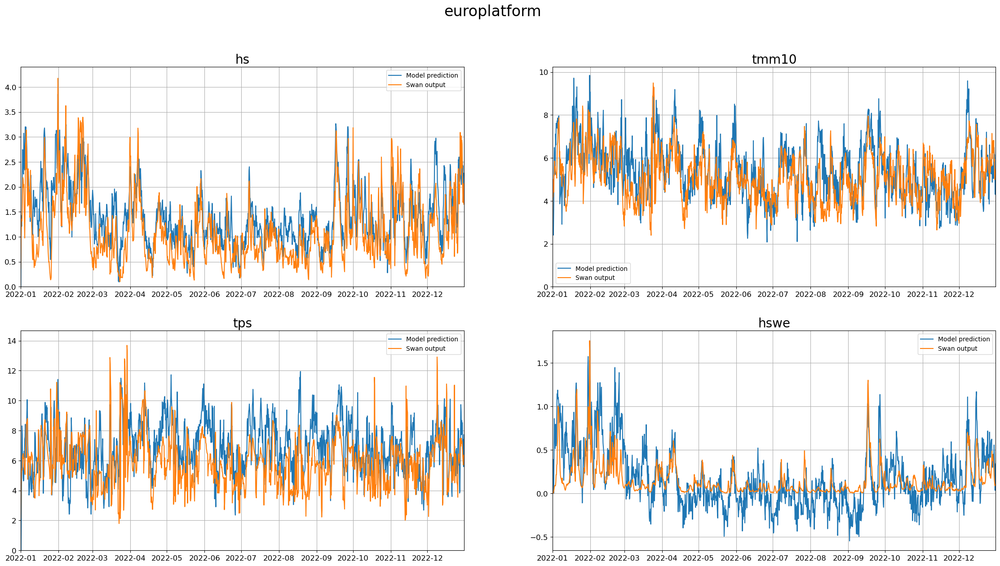

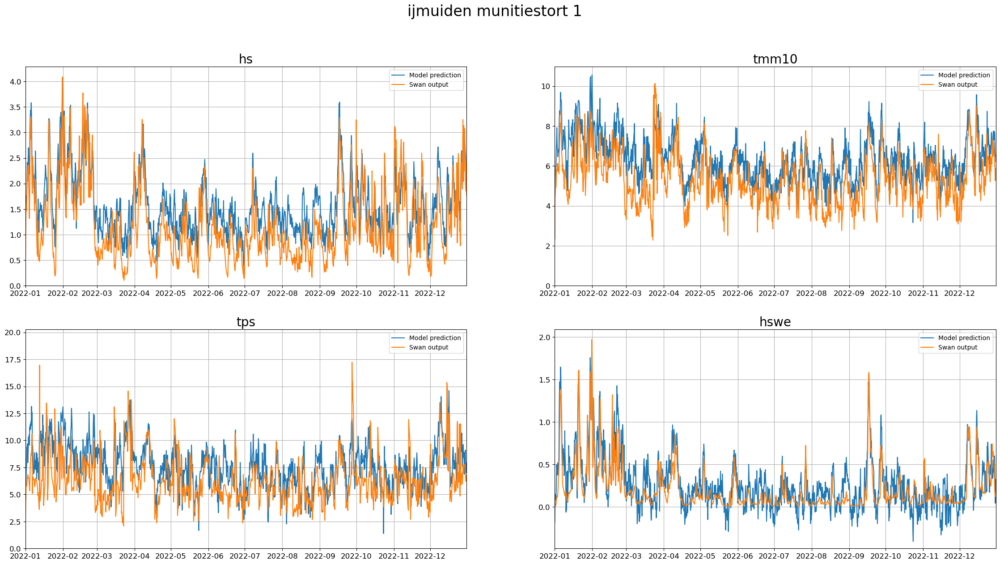

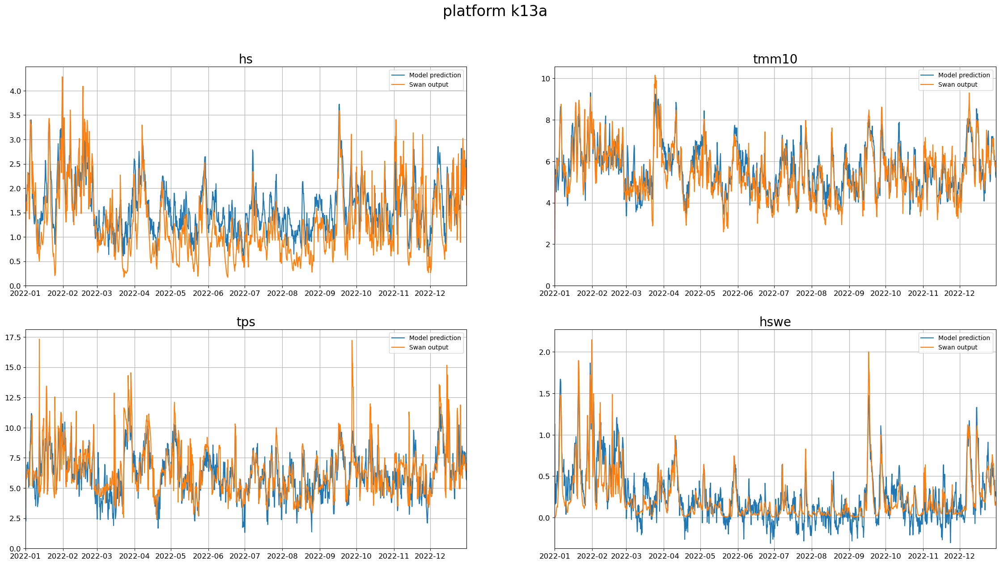

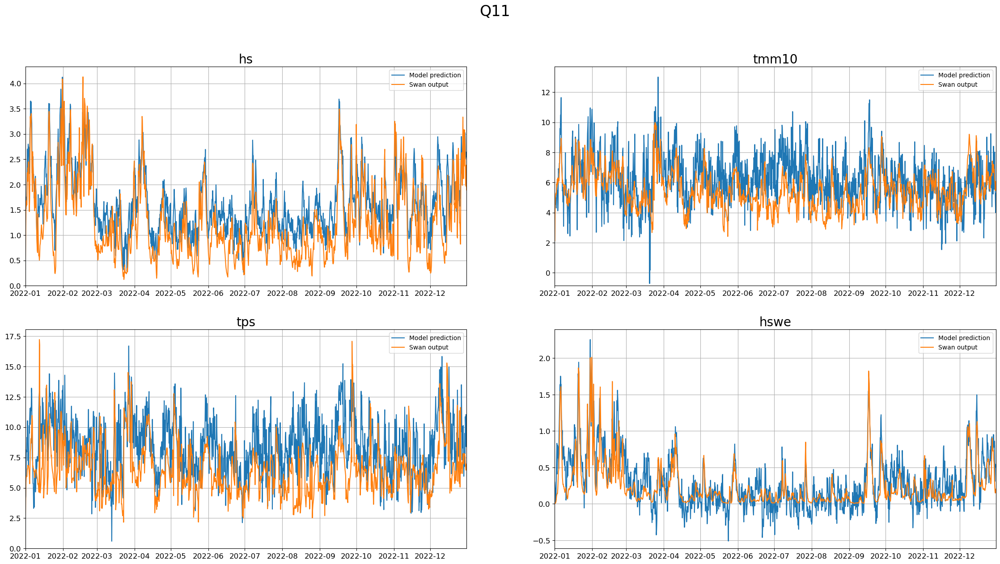

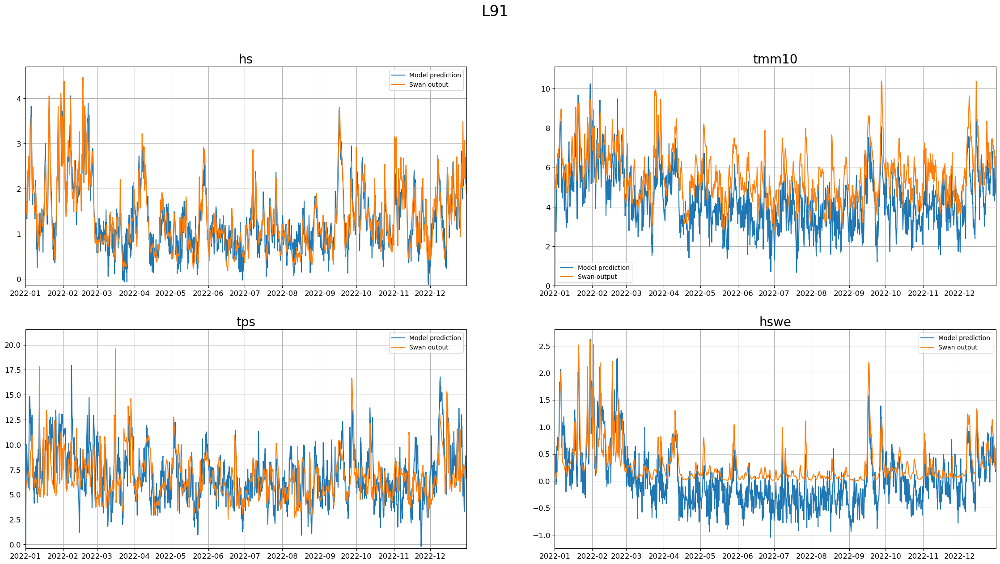

...

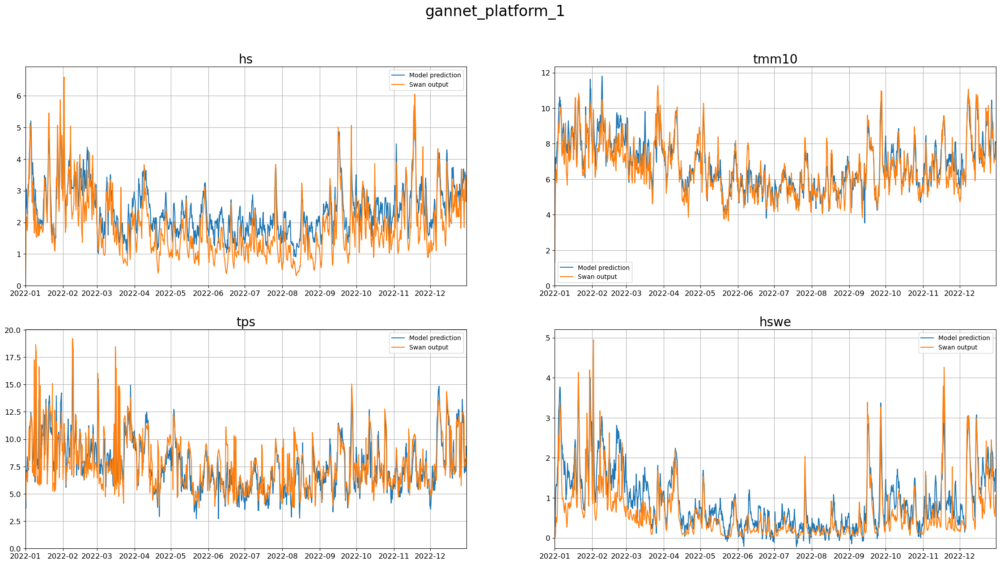

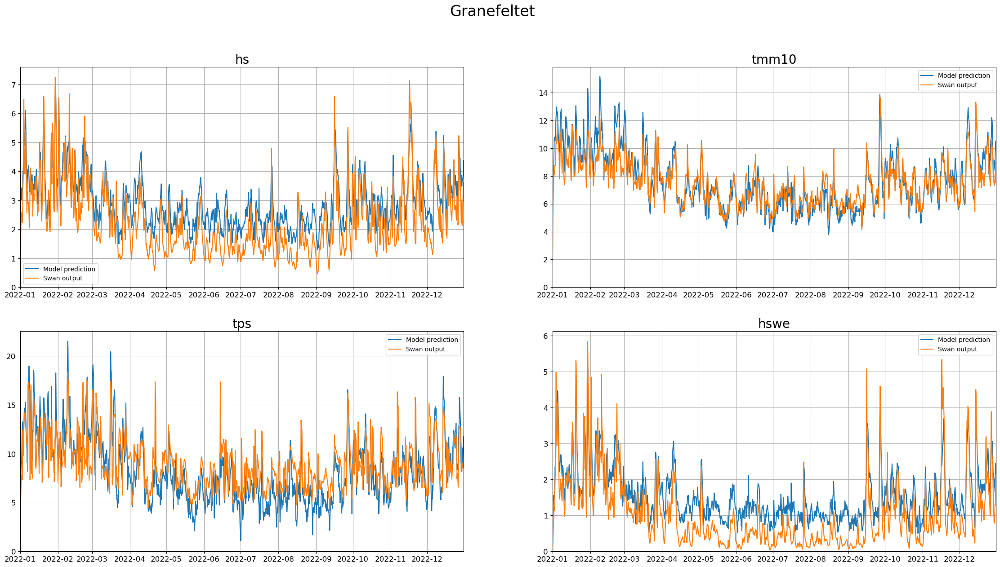

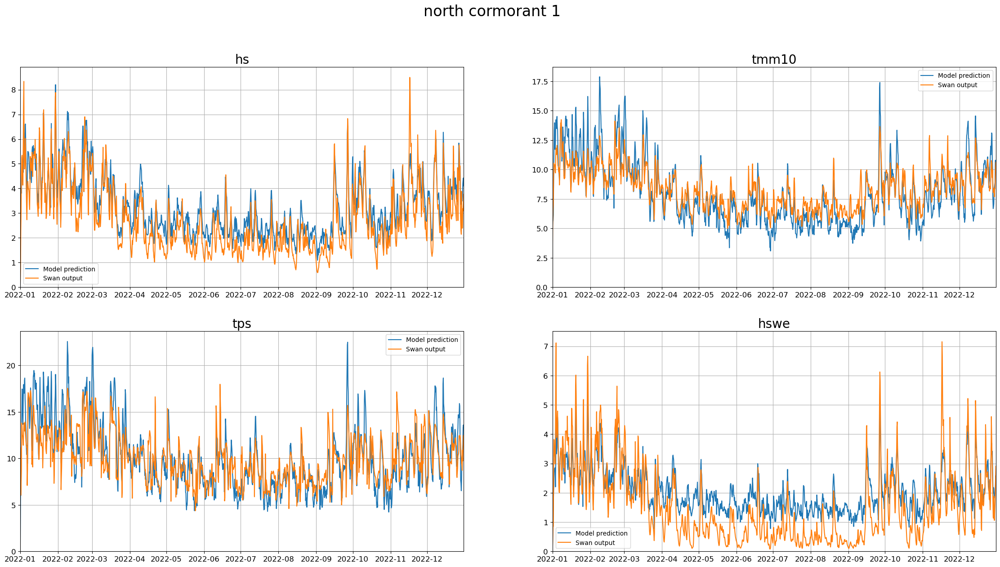

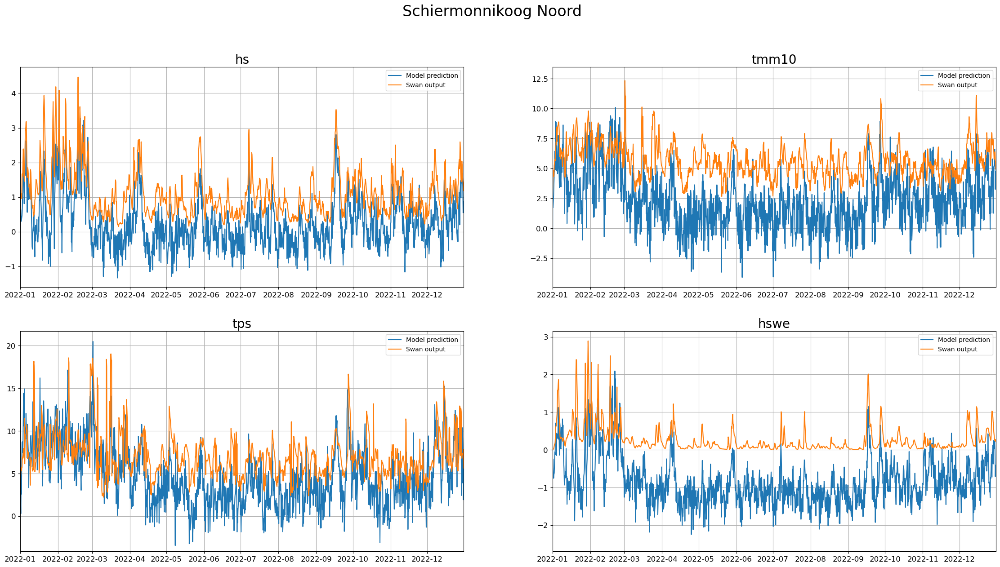

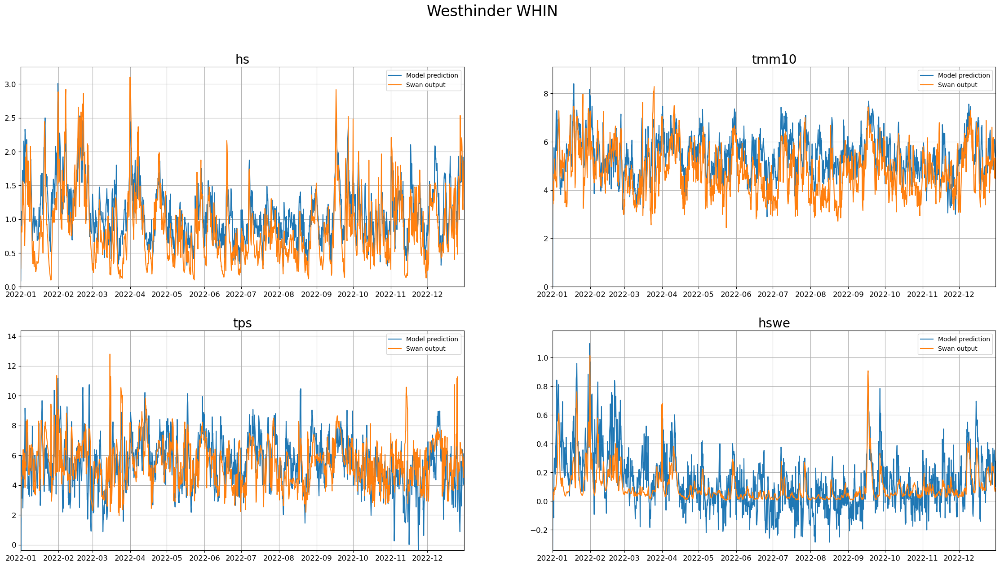

In [13]:
for location in locations.keys():
    plot_timeseries(location)

In [15]:
def mae(x, y):
    return np.nanmean(abs(x - y))

def mse(x, y):
    return np.nanmean(np.power(x - y, 2))

def rmse(x, y):
    return np.sqrt(np.nanmean(np.power(x - y, 2)))

In [16]:
for var in important_output_variables:
    for i in range(len(ens_30_pred[var])):
        land_mask = np.isnan(ens_30_true[var][i])
        ens_30_pred[var][i][np.where(land_mask)] = np.nan

In [17]:
maes = {}
mses = {}
rmses = {}
for var in important_output_variables:
    maes[var] = []
    mses[var] = []
    rmses[var] = []
    for i in range(len(ens_30_pred[var])):
        maes[var].append(mae(ens_30_pred[var][i], ens_30_true[var][i]))
        mses[var].append(mse(ens_30_pred[var][i], ens_30_true[var][i]))
        rmses[var].append(rmse(ens_30_pred[var][i], ens_30_true[var][i]))

In [18]:
for var in important_output_variables:
    print(f"Errors for {var}: mean MAE: {np.mean(maes[var])}, std MAE: {np.std(maes[var])}")
    print(f"Errors for {var}: mean MSE: {np.mean(mses[var])}, std MSE: {np.std(mses[var])}")
    print(f"Errors for {var}: mean RMSE: {np.mean(rmses[var])}, std RMSE: {np.std(rmses[var])}")

Errors for hs: mean MAE: 1.6462030410766602, std MAE: 0.2678971290588379
Errors for hs: mean MSE: 15.110797882080078, std MSE: 1.1420120000839233
Errors for hs: mean RMSE: 3.88457989692688, std RMSE: 0.14435896277427673
Errors for tmm10: mean MAE: 5.687902450561523, std MAE: 1.0428457260131836
Errors for tmm10: mean MSE: 172.9241485595703, std MSE: 10.832533836364746
Errors for tmm10: mean RMSE: 13.143824577331543, std RMSE: 0.4049947261810303
Errors for tps: mean MAE: 4.341441631317139, std MAE: 1.3546446561813354
Errors for tps: mean MSE: 55.90805435180664, std MSE: 24.948259353637695
Errors for tps: mean RMSE: 7.353725433349609, std RMSE: 1.3530657291412354
Errors for hswe: mean MAE: 1.4933996200561523, std MAE: 0.26085716485977173
Errors for hswe: mean MSE: 12.488988876342773, std MSE: 1.0573393106460571
Errors for hswe: mean RMSE: 3.5309500694274902, std RMSE: 0.1462264508008957


In [19]:
correlations = {}
for var in important_output_variables:
    correlations[var] = []
    for i in range(len(ens_30_pred[var])):
        mask = np.ma.masked_invalid(ens_30_pred[var][i])
        v_pred = ens_30_pred[var][i][~mask.mask].flatten()
        v_true = ens_30_true[var][i][~mask.mask].flatten()
        
        correlations[var].append(pearsonr(v_pred, v_true))

In [20]:
for var in important_output_variables:
    print(f"Mean correlation for {var}: {np.mean(correlations[var])}")

Mean correlation for hs: 0.17783237723561998
Mean correlation for tmm10: 0.07836661127465909
Mean correlation for tps: 0.1116648373472876
Mean correlation for hswe: 0.15485933504010407


In [21]:
cmaes = {}
for var in important_output_variables:
    cmaes[var] = []
    cmaes[var] = np.array([abs(ens_30_pred[var][i] - ens_30_true[var][i]) for i in range(len(ens_30_pred[var]))])
    cmaes[var] = np.sum(cmaes[var], axis=0) / len(ens_30_pred[var])

In [22]:
lon_ticks = np.arange(0, len(val_ds.longitude), int(len(val_ds.longitude) / 6)).astype(np.int32)
lat_ticks = np.arange(0, len(val_ds.latitude), int(len(val_ds.latitude) / 6)).astype(np.int32)

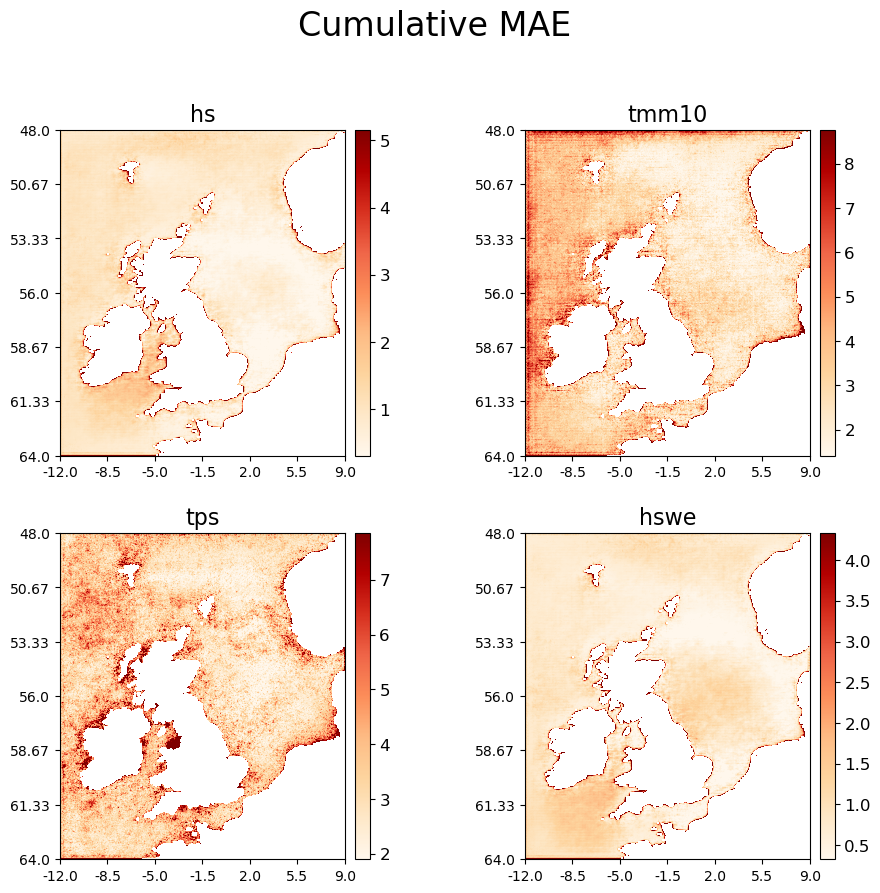

In [23]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
fig.suptitle(f'Cumulative MAE', fontsize=24)
plt.subplots_adjust(wspace=0.5, hspace=0.1)
for i, var in enumerate(important_output_variables):
    column = i % 2
    row = i // 2

    flipped_image = np.flip(cmaes[var], axis=0)
    
    vmin, vmax = np.nanquantile(flipped_image, [0.05, 0.95])
    im = axes[row, column].imshow(flipped_image, vmin=vmin, vmax=vmax, cmap='OrRd')
    
    divider = make_axes_locatable(axes[row, column])
    cax = divider.append_axes("right", size="5%", pad=0.10)
    cb = plt.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=12)
    cb.ax.yaxis.get_offset_text().set(size=12)

    axes[row, column].set_title(var, size=16)
    axes[row, column].set_xticks(lon_ticks, np.round(val_ds.longitude.values[lon_ticks], 2))
    axes[row, column].set_yticks(lat_ticks, np.round(val_ds.latitude.values[lat_ticks], 2))

fig.savefig(figure_dir / 'cmae-storm.png')

In [24]:
df_dict = {
    'mean MAE': [np.mean(maes[var]) for var in important_output_variables],
    'mean MSE': [np.mean(mses[var]) for var in important_output_variables],
    'mean RMSE': [np.mean(rmses[var]) for var in important_output_variables],
    'mean Correlation': [np.mean(correlations[var]) for var in important_output_variables],
    'std MAE': [np.std(maes[var]) for var in important_output_variables],
    'std MSE': [np.std(mses[var]) for var in important_output_variables],
    'std RMSE': [np.std(rmses[var]) for var in important_output_variables],
    'std Correlation': [np.std(correlations[var]) for var in important_output_variables],
          }
df = pd.DataFrame(df_dict, index=important_output_variables)
df

,mean MAE,mean MSE,mean RMSE,mean Correlation,std MAE,std MSE,std RMSE,std Correlation
hs,1.646203,15.110798,3.884580,0.177832,0.267897,1.142012,0.144359,0.213676
tmm10,5.687902,172.924149,13.143825,0.078367,1.042846,10.832534,0.404995,0.104577
tps,4.341442,55.908054,7.353725,0.111665,1.354645,24.948259,1.353066,0.130437
hswe,1.493400,12.488989,3.530950,0.154859,0.260857,1.057339,0.146226,0.197656


In [25]:
df.to_csv(figure_dir / 'stats-storm.csv')